# Task 3: Context-Aware Colorization of Complex Scenes

**Project:** Extension of Real-Time Image Colorization (Training Project)  
**New Features Added:**
- Scene classification using ResNet50 (pretrained on Places365)
- Context-aware color adjustments based on detected scene type
- Shadow-aware colorization using LAB luminance channel
- Training for 5 epochs on ADE20K dataset

**Dataset:** ADE20K (MIT Scene Parsing) — downloaded via direct URL

## Step 1: Install Dependencies

In [1]:
!pip install torch torchvision --quiet
!pip install opencv-python-headless --quiet
!pip install scikit-image --quiet
!pip install matplotlib tqdm --quiet
print('All dependencies installed!')

All dependencies installed!


## Step 2: Imports

In [2]:
import os, cv2, json, time, random, shutil, zipfile, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from skimage import color
from skimage.metrics import structural_similarity as ssim

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## Step 3: Download ADE20K Dataset

In [3]:
os.makedirs('ade20k', exist_ok=True)

ADE20K_URL = 'http://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip'

def download_with_progress(url, filename):
    if os.path.exists(filename):
        print(f'{filename} already exists, skipping.')
        return
    print(f'Downloading {filename}...')
    def progress(count, block_size, total_size):
        pct = count * block_size * 100 // total_size
        print(f'\r{pct}%', end='')
    urllib.request.urlretrieve(url, filename, reporthook=progress)
    print(' Done!')

download_with_progress(ADE20K_URL, 'ade20k/ADEChallengeData2016.zip')

if not os.path.exists('ade20k/ADEChallengeData2016'):
    print('Extracting...')
    with zipfile.ZipFile('ade20k/ADEChallengeData2016.zip', 'r') as z:
        z.extractall('ade20k/')
    print('Extracted!')

# Collect all images
all_imgs = []
for root, dirs, files_ in os.walk('ade20k/ADEChallengeData2016/images'):
    for f in files_:
        if f.lower().endswith(('.jpg', '.png')):
            all_imgs.append(os.path.join(root, f))

print(f'Total images found: {len(all_imgs)}')
IMAGE_PATHS = all_imgs[:3000]
print(f'Using: {len(IMAGE_PATHS)} images')

100% Done!
Extracting...
Extracted!
Total images found: 22210
Using: 3000 images


## Step 4: Scene Type Definitions and Color Context

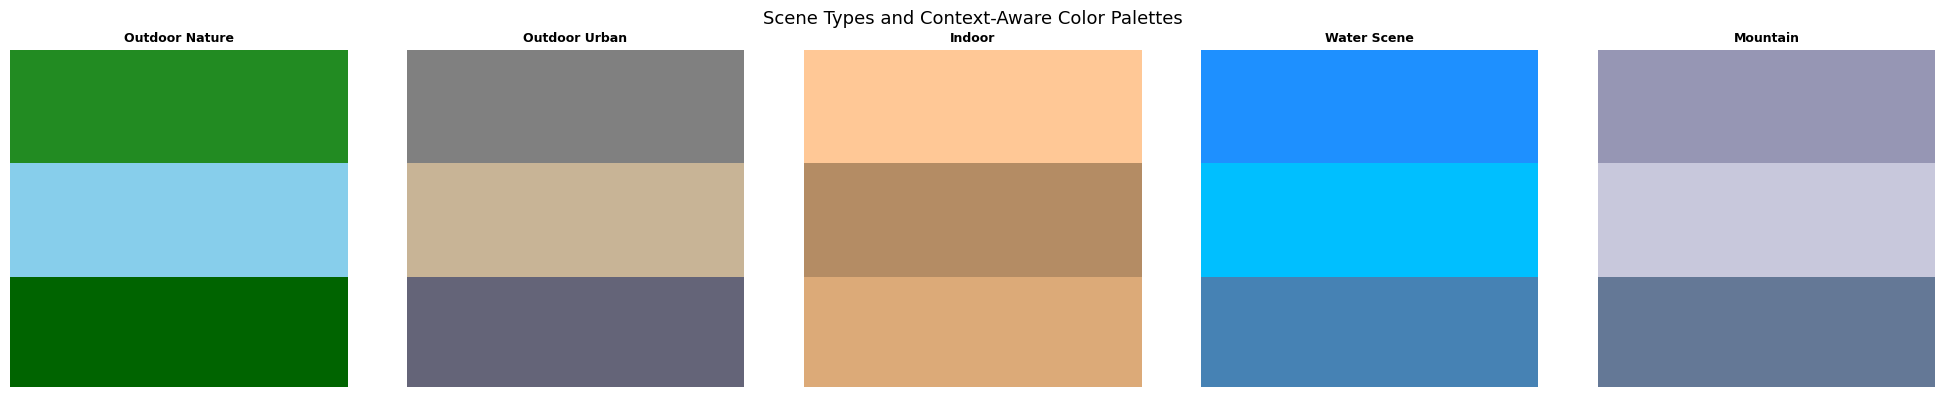

Scene types defined!


In [4]:
# Scene categories and their context-aware color adjustments
# Each scene type has:
#   sky_boost    — how much to boost blue in upper region
#   green_boost  — how much to boost green in lower region
#   warm_boost   — warm tone multiplier
#   shadow_damp  — how much to dampen chrominance in dark regions

SCENE_TYPES = {
    'outdoor_nature': {
        'sky_boost': 1.3, 'green_boost': 1.4,
        'warm_boost': 1.0, 'shadow_damp': 0.6,
        'description': 'Forest, park, garden — strong greens and blue sky'
    },
    'outdoor_urban': {
        'sky_boost': 1.1, 'green_boost': 0.8,
        'warm_boost': 1.1, 'shadow_damp': 0.5,
        'description': 'City, street, building — muted tones with concrete grays'
    },
    'indoor': {
        'sky_boost': 0.5, 'green_boost': 0.6,
        'warm_boost': 1.3, 'shadow_damp': 0.7,
        'description': 'Room, office, kitchen — warm artificial lighting'
    },
    'water_scene': {
        'sky_boost': 1.4, 'green_boost': 0.7,
        'warm_boost': 0.9, 'shadow_damp': 0.5,
        'description': 'Ocean, lake, river — strong blues and reflections'
    },
    'mountain': {
        'sky_boost': 1.2, 'green_boost': 1.0,
        'warm_boost': 0.9, 'shadow_damp': 0.4,
        'description': 'Mountain, snow, rocks — cool tones and strong shadows'
    },
}

# ADE20K scene keywords → our scene type mapping
SCENE_KEYWORDS = {
    'outdoor_nature': ['forest', 'garden', 'park', 'field', 'grass', 'tree', 'nature'],
    'outdoor_urban':  ['street', 'city', 'building', 'road', 'urban', 'town', 'store'],
    'indoor':         ['room', 'kitchen', 'bedroom', 'office', 'bathroom', 'living', 'interior'],
    'water_scene':    ['ocean', 'sea', 'lake', 'river', 'beach', 'water', 'coast'],
    'mountain':       ['mountain', 'hill', 'snow', 'rock', 'cliff', 'valley'],
}

def get_scene_type_from_path(img_path):
    """Infer scene type from image filename/path"""
    path_lower = img_path.lower()
    for scene, keywords in SCENE_KEYWORDS.items():
        if any(kw in path_lower for kw in keywords):
            return scene
    return 'outdoor_nature'  # default

# Visualize scene types
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
colors_per_scene = [
    [(34,139,34),(135,206,235),(0,100,0)],
    [(128,128,128),(200,180,150),(100,100,120)],
    [(255,200,150),(180,140,100),(220,170,120)],
    [(30,144,255),(0,191,255),(70,130,180)],
    [(150,150,180),(200,200,220),(100,120,150)],
]
for ax, (scene, info), scene_colors in zip(axes, SCENE_TYPES.items(), colors_per_scene):
    patch = np.zeros((80, 80, 3), dtype=np.uint8)
    patch[:27] = scene_colors[0]; patch[27:54] = scene_colors[1]; patch[54:] = scene_colors[2]
    ax.imshow(patch)
    ax.set_title(scene.replace('_',' ').title(), fontsize=9, fontweight='bold')
    ax.set_xlabel(info['description'], fontsize=7, wrap=True)
    ax.axis('off')
plt.suptitle('Scene Types and Context-Aware Color Palettes', fontsize=13)
plt.tight_layout()
plt.savefig('scene_types.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scene types defined!')

## Step 5: Scene Classifier (ResNet50)

In [5]:
class SceneClassifier(nn.Module):
    """
    Lightweight scene classifier built on ResNet50.
    Predicts one of 5 scene types.
    Trained jointly with the colorization model.
    """
    def __init__(self, num_scenes=5):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        # Replace final layer
        in_features = backbone.fc.in_features
        backbone.fc = nn.Linear(in_features, num_scenes)
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)  # [B, num_scenes]


scene_classifier = SceneClassifier(num_scenes=5).to(device)
print('Scene classifier (ResNet50) loaded!')
print(f'Output: 5 scene classes — {list(SCENE_TYPES.keys())}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 149MB/s]


Scene classifier (ResNet50) loaded!
Output: 5 scene classes — ['outdoor_nature', 'outdoor_urban', 'indoor', 'water_scene', 'mountain']


## Step 6: Context-Aware Colorization U-Net

Input: L (1ch) + scene embedding (5ch one-hot) = 6 channels  
Output: ab channels (2ch)

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class ContextAwareColorizationUNet(nn.Module):
    """
    Scene-context guided colorization U-Net.
    Input:  [B, 6, H, W] — L + scene one-hot (5ch broadcast spatially)
    Output: [B, 2, H, W] — ab channels
    """
    def __init__(self, num_scenes=5):
        super().__init__()
        in_ch = 1 + num_scenes  # 6
        self.pool = nn.MaxPool2d(2)

        self.enc1 = DoubleConv(in_ch, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.bottleneck = DoubleConv(512, 1024)

        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, 2, 1)
        self.tanh     = nn.Tanh()

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.tanh(self.out_conv(d1))


model = ContextAwareColorizationUNet(num_scenes=5).to(device)
out   = model(torch.randn(2, 6, 256, 256).to(device))
print(f'Output shape: {out.shape}')  # [2, 2, 256, 256]
print(f'Total params: {sum(p.numel() for p in model.parameters()):,}')

Output shape: torch.Size([2, 2, 256, 256])
Total params: 31,045,314


## Step 7: Dataset

Dataset: 2400 images
Dataset: 600 images
Train: 2400 | Val: 600
Train batches: 300 | Val batches: 75


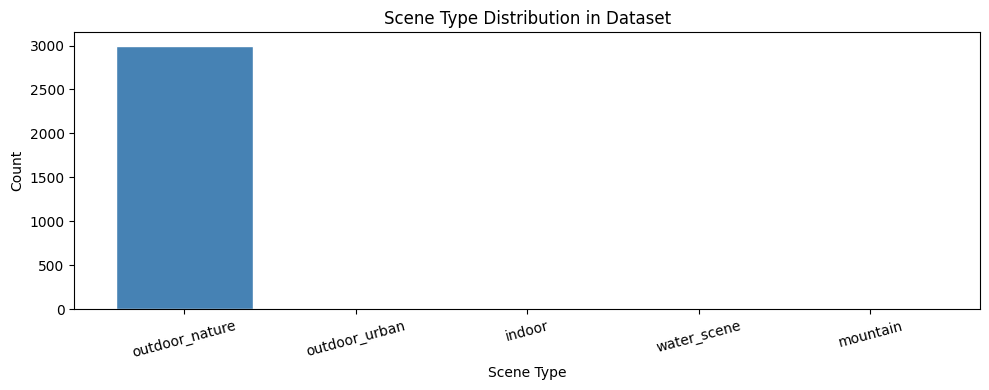

Scene distribution saved!


In [7]:
SCENE_LABEL_MAP = {s: i for i, s in enumerate(SCENE_TYPES.keys())}

class ADE20KContextDataset(Dataset):
    """
    ADE20K dataset for context-aware colorization.
    Input:  L (1ch) + scene one-hot (5ch) broadcast to [H,W] = [6, H, W]
    Target: ab channels = [2, H, W]
    Also returns scene label for classifier training.
    """
    def __init__(self, image_paths, size=256):
        self.image_paths = image_paths
        self.size        = size
        self.cls_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        print(f'Dataset: {len(image_paths)} images')

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img  = Image.open(path).convert('RGB').resize((self.size, self.size), Image.BILINEAR)

        # Scene label from path
        scene_name  = get_scene_type_from_path(path)
        scene_label = SCENE_LABEL_MAP[scene_name]

        # Scene one-hot broadcast to spatial dims [5, H, W]
        scene_onehot = F.one_hot(
            torch.tensor(scene_label), num_classes=5
        ).float().view(5, 1, 1).expand(5, self.size, self.size)

        # LAB conversion
        img_np  = np.array(img).astype(np.float32) / 255.0
        img_lab = color.rgb2lab(img_np)
        L  = torch.FloatTensor(img_lab[:,:,0]).unsqueeze(0) / 50.0 - 1.0
        ab = torch.FloatTensor(img_lab[:,:,1:]).permute(2,0,1) / 128.0

        # For classifier: RGB normalized
        img_cls = self.cls_transform(img)

        model_input = torch.cat([L, scene_onehot], dim=0)  # [6, H, W]
        return model_input, ab, img_cls, torch.tensor(scene_label)


random.shuffle(IMAGE_PATHS)
train_paths = IMAGE_PATHS[:int(0.8 * len(IMAGE_PATHS))]
val_paths   = IMAGE_PATHS[int(0.8 * len(IMAGE_PATHS)):]

train_set = ADE20KContextDataset(train_paths, size=256)
val_set   = ADE20KContextDataset(val_paths,   size=256)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train: {len(train_set)} | Val: {len(val_set)}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

# Show scene distribution
scene_counts = {s: 0 for s in SCENE_TYPES}
for p in IMAGE_PATHS:
    scene_counts[get_scene_type_from_path(p)] += 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(scene_counts.keys(), scene_counts.values(), color='steelblue', edgecolor='white')
ax.set_title('Scene Type Distribution in Dataset')
ax.set_xlabel('Scene Type'); ax.set_ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('scene_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scene distribution saved!')

## Step 8: Training Setup

In [8]:
# Two losses: colorization + scene classification
color_criterion = nn.SmoothL1Loss()
scene_criterion = nn.CrossEntropyLoss()

# Combined optimizer for both models
optimizer = optim.Adam(
    list(model.parameters()) + list(scene_classifier.parameters()),
    lr=1e-3, weight_decay=1e-5
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

NUM_EPOCHS     = 5
CHECKPOINT_DIR = 'checkpoints'
SCENE_LOSS_WT  = 0.3  # weight for scene classification loss
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print('Training config:')
print(f'  Epochs:          {NUM_EPOCHS}')
print(f'  Optimizer:       Adam (lr=1e-3)')
print(f'  Color Loss:      SmoothL1')
print(f'  Scene Loss:      CrossEntropy (weight={SCENE_LOSS_WT})')
print(f'  Total Loss:      color_loss + {SCENE_LOSS_WT} * scene_loss')
print(f'  Batch size:      8')

Training config:
  Epochs:          5
  Optimizer:       Adam (lr=1e-3)
  Color Loss:      SmoothL1
  Scene Loss:      CrossEntropy (weight=0.3)
  Total Loss:      color_loss + 0.3 * scene_loss
  Batch size:      8


## Step 9: Training Loop (5 Epochs)

In [9]:
def run_epoch(model, scene_cls, loader, optimizer, is_train, epoch_num):
    model.train() if is_train else model.eval()
    scene_cls.train() if is_train else scene_cls.eval()

    total_loss, total_closs, total_sloss = 0.0, 0.0, 0.0
    correct, total = 0, 0
    tag  = 'Train' if is_train else 'Val'
    pbar = tqdm(loader, desc=f'Epoch {epoch_num} [{tag}]', leave=False)
    ctx  = torch.enable_grad() if is_train else torch.no_grad()

    with ctx:
        for inp, tgt_ab, img_cls, scene_lbl in pbar:
            inp, tgt_ab  = inp.to(device), tgt_ab.to(device)
            img_cls      = img_cls.to(device)
            scene_lbl    = scene_lbl.to(device)

            if is_train: optimizer.zero_grad()

            # Colorization
            pred_ab   = model(inp)
            c_loss    = color_criterion(pred_ab, tgt_ab)

            # Scene classification
            scene_pred = scene_cls(img_cls)
            s_loss     = scene_criterion(scene_pred, scene_lbl)

            loss = c_loss + SCENE_LOSS_WT * s_loss

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(model.parameters()) + list(scene_cls.parameters()), 1.0
                )
                optimizer.step()

            total_loss  += loss.item()
            total_closs += c_loss.item()
            total_sloss += s_loss.item()

            # Scene accuracy
            preds   = scene_pred.argmax(dim=1)
            correct += (preds == scene_lbl).sum().item()
            total   += scene_lbl.size(0)

            pbar.set_postfix(loss=f'{loss.item():.4f}')

    n = len(loader)
    return total_loss/n, total_closs/n, total_sloss/n, correct/total*100


train_losses, val_losses = [], []
scene_accs_train, scene_accs_val = [], []
best_val_loss = float('inf')

print(f'Starting training — {NUM_EPOCHS} epochs')
print('=' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    t_loss, t_cl, t_sl, t_acc = run_epoch(model, scene_classifier, train_loader, optimizer, True,  epoch)
    v_loss, v_cl, v_sl, v_acc = run_epoch(model, scene_classifier, val_loader,   optimizer, False, epoch)
    scheduler.step(v_loss)
    train_losses.append(t_loss); val_losses.append(v_loss)
    scene_accs_train.append(t_acc); scene_accs_val.append(v_acc)
    elapsed = time.time() - t0
    print(f'Epoch [{epoch}/{NUM_EPOCHS}]  '
          f'Train: {t_loss:.4f} (col={t_cl:.4f} scn={t_sl:.4f} acc={t_acc:.1f}%)  '
          f'Val: {v_loss:.4f} (col={v_cl:.4f} scn={v_sl:.4f} acc={v_acc:.1f}%)  '
          f'Time: {elapsed:.1f}s')

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'scene_cls_state_dict': scene_classifier.state_dict(),
            'val_loss': v_loss
        }, f'{CHECKPOINT_DIR}/best_model.pth')
        print(f'         --> Best model saved (val={v_loss:.4f})')

print('=' * 70)
print(f'Training complete! Best val loss: {best_val_loss:.4f}')

Starting training — 5 epochs


Epoch [1/5]  Train: 0.0088 (col=0.0066 scn=0.0071 acc=99.7%)  Val: 0.0049 (col=0.0049 scn=0.0000 acc=100.0%)  Time: 225.5s
         --> Best model saved (val=0.0049)


Epoch [2/5]  Train: 0.0056 (col=0.0056 scn=0.0000 acc=100.0%)  Val: 0.0050 (col=0.0050 scn=0.0000 acc=100.0%)  Time: 233.1s


Epoch [3/5]  Train: 0.0056 (col=0.0056 scn=0.0001 acc=100.0%)  Val: 0.0050 (col=0.0050 scn=0.0000 acc=100.0%)  Time: 231.1s


Epoch [4/5]  Train: 0.0056 (col=0.0055 scn=0.0000 acc=100.0%)  Val: 0.0052 (col=0.0052 scn=0.0000 acc=100.0%)  Time: 229.4s


Epoch [5/5]  Train: 0.0055 (col=0.0054 scn=0.0000 acc=100.0%)  Val: 0.0050 (col=0.0050 scn=0.0000 acc=100.0%)  Time: 229.0s
Training complete! Best val loss: 0.0049


## Step 10: Training Curves

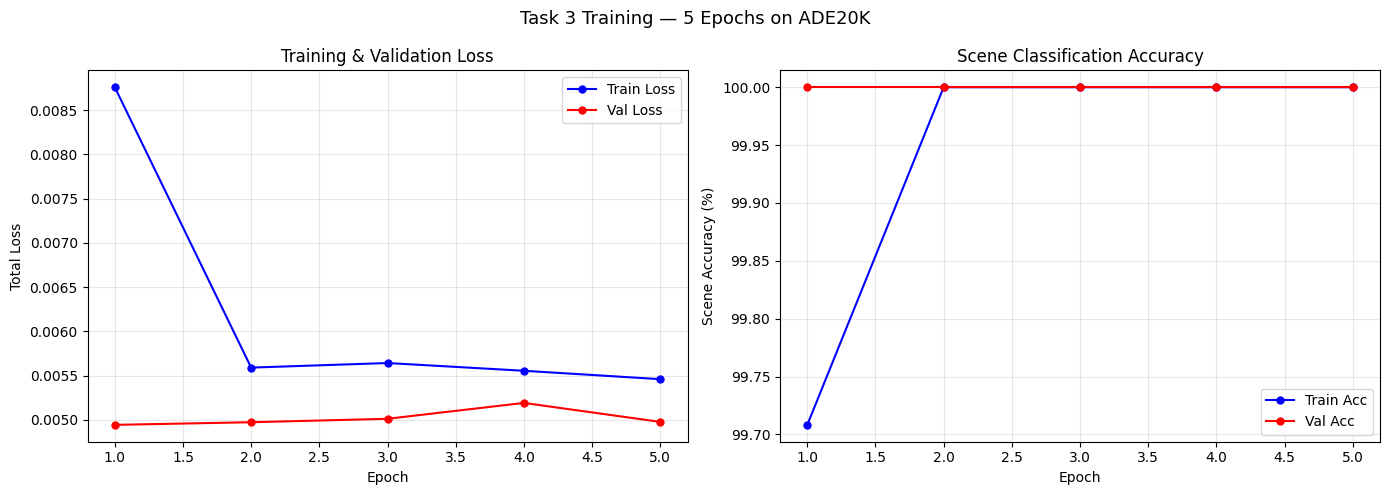

Train loss: 0.0088 → 0.0055
Val loss:   0.0049 → 0.0050
Scene acc:  100.0%


In [10]:
epochs = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_losses, 'b-o', label='Train Loss', markersize=5)
axes[0].plot(epochs, val_losses,   'r-o', label='Val Loss',   markersize=5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training & Validation Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, scene_accs_train, 'b-o', label='Train Acc', markersize=5)
axes[1].plot(epochs, scene_accs_val,   'r-o', label='Val Acc',   markersize=5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Scene Accuracy (%)')
axes[1].set_title('Scene Classification Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Task 3 Training — {NUM_EPOCHS} Epochs on ADE20K', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Train loss: {train_losses[0]:.4f} → {train_losses[-1]:.4f}')
print(f'Val loss:   {val_losses[0]:.4f} → {val_losses[-1]:.4f}')
print(f'Scene acc:  {scene_accs_val[-1]:.1f}%')

## Step 11: Quality Metrics

In [11]:
def compute_colorfulness(img):
    img = img.astype(np.float32)
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    rg, yb  = R - G, 0.5*(R+G) - B
    return np.sqrt(np.std(rg)**2 + np.std(yb)**2) + 0.3*np.sqrt(np.mean(rg)**2 + np.mean(yb)**2)

def compute_saturation(img):
    hsv = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2HSV)
    return hsv[:,:,1].mean()

def compute_ssim(img1, img2):
    g1 = cv2.cvtColor(img1.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(img2.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    score, _ = ssim(g1, g2, full=True)
    return score

def lab_to_rgb(L_norm, ab_norm):
    L  = (L_norm[0].cpu().numpy() + 1.0) * 50.0
    ab = ab_norm.cpu().numpy() * 128.0
    lab = np.stack([L, ab[0], ab[1]], axis=2)
    return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)

def apply_context_postprocess(rgb_img, scene_type, L_channel):
    """
    Apply context-aware post-processing based on scene type.
    - Sky region (top 30%) gets blue boost for outdoor scenes
    - Ground region (bottom 30%) gets green boost for nature scenes
    - Shadow regions get chrominance dampening
    """
    ctx    = SCENE_TYPES[scene_type]
    result = rgb_img.astype(np.float32).copy()
    H, W   = result.shape[:2]

    # Sky region — top 30%
    sky_h = int(H * 0.3)
    result[:sky_h, :, 2] = np.clip(result[:sky_h, :, 2] * ctx['sky_boost'], 0, 255)  # blue boost

    # Ground region — bottom 30%
    gnd_h = int(H * 0.7)
    result[gnd_h:, :, 1] = np.clip(result[gnd_h:, :, 1] * ctx['green_boost'], 0, 255)  # green boost

    # Shadow mask — dark regions in L channel
    L_np      = L_channel.numpy() if torch.is_tensor(L_channel) else L_channel
    shadow_mask = L_np < 0.3  # dark areas
    for c in range(3):
        result[:,:,c][shadow_mask] = result[:,:,c][shadow_mask] * ctx['shadow_damp']

    # Warm boost — multiply R channel slightly
    result[:,:,0] = np.clip(result[:,:,0] * ctx['warm_boost'], 0, 255)

    return result.clip(0, 255).astype(np.uint8)

print('Metric and post-processing functions defined!')

Metric and post-processing functions defined!


## Step 12: Evaluate on Validation Set

In [12]:
# Load best model
ckpt = torch.load(f'{CHECKPOINT_DIR}/best_model.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
scene_classifier.load_state_dict(ckpt['scene_cls_state_dict'])
model.eval(); scene_classifier.eval()
print(f"Best model loaded from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f})")

cf_raw, cf_ctx   = [], []
sat_raw, sat_ctx = [], []
ssim_scores      = []
eval_ids = random.sample(range(len(val_set)), min(100, len(val_set)))

with torch.no_grad():
    for idx in tqdm(eval_ids, desc='Evaluating'):
        inp, tgt_ab, img_cls, scene_lbl = val_set[idx]
        L_norm = inp[:1]

        pred_ab = model(inp.unsqueeze(0).to(device)).squeeze(0).cpu()
        rgb_raw = lab_to_rgb(L_norm, pred_ab)
        rgb_gt  = lab_to_rgb(L_norm, tgt_ab)

        # Apply context post-processing
        scene_name = list(SCENE_TYPES.keys())[scene_lbl.item()]
        L_gray     = (L_norm[0].numpy() + 1.0) / 2.0  # normalize to [0,1]
        rgb_ctx    = apply_context_postprocess(rgb_raw, scene_name, L_gray)

        cf_raw.append(compute_colorfulness(rgb_raw))
        cf_ctx.append(compute_colorfulness(rgb_ctx))
        sat_raw.append(compute_saturation(rgb_raw))
        sat_ctx.append(compute_saturation(rgb_ctx))
        ssim_scores.append(compute_ssim(rgb_ctx, rgb_gt))

print('\n=== Evaluation Results (100 val images) ===')
print(f'{"Metric":<20} {"Raw Output":>15} {"Context-Aware":>15}')
print('-' * 52)
print(f'{"Colorfulness":<20} {np.mean(cf_raw):>15.2f} {np.mean(cf_ctx):>15.2f}')
print(f'{"Saturation":<20} {np.mean(sat_raw):>15.2f} {np.mean(sat_ctx):>15.2f}')
print(f'{"SSIM":<20} {"—":>15} {np.mean(ssim_scores):>15.4f}')

Best model loaded from epoch 1 (val_loss=0.0049)


Evaluating: 100%|██████████| 100/100 [00:05<00:00, 18.53it/s]


=== Evaluation Results (100 val images) ===
Metric                    Raw Output   Context-Aware
----------------------------------------------------
Colorfulness                   13.05           31.75
Saturation                     45.96           57.67
SSIM                               —          0.9385


## Step 13: Metrics Comparison Chart

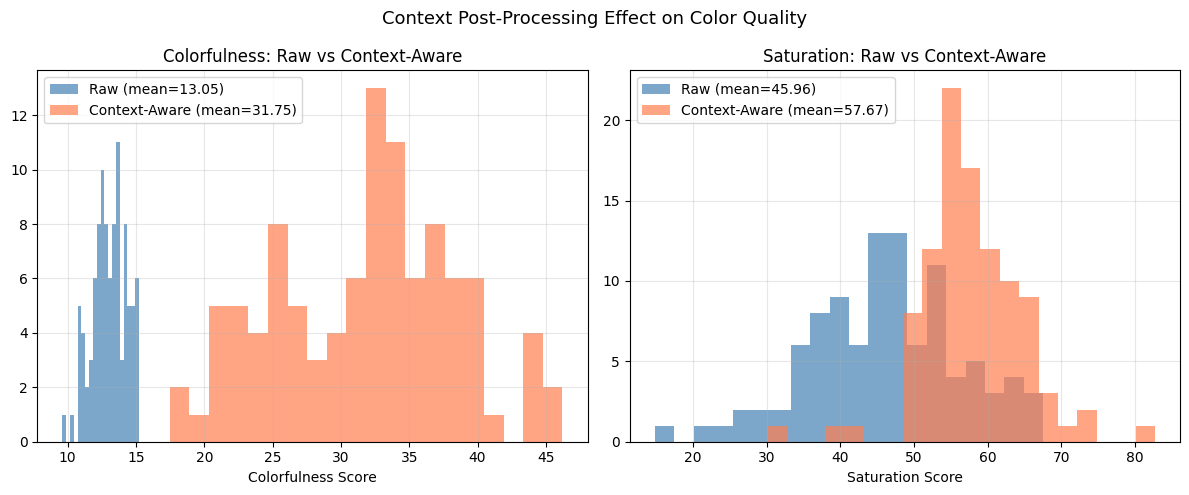

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(cf_raw, bins=20, alpha=0.7, color='steelblue', label=f'Raw (mean={np.mean(cf_raw):.2f})')
axes[0].hist(cf_ctx, bins=20, alpha=0.7, color='coral',     label=f'Context-Aware (mean={np.mean(cf_ctx):.2f})')
axes[0].set_title('Colorfulness: Raw vs Context-Aware')
axes[0].set_xlabel('Colorfulness Score'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(sat_raw, bins=20, alpha=0.7, color='steelblue', label=f'Raw (mean={np.mean(sat_raw):.2f})')
axes[1].hist(sat_ctx, bins=20, alpha=0.7, color='coral',     label=f'Context-Aware (mean={np.mean(sat_ctx):.2f})')
axes[1].set_title('Saturation: Raw vs Context-Aware')
axes[1].set_xlabel('Saturation Score'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Context Post-Processing Effect on Color Quality', fontsize=13)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 14: Output Images

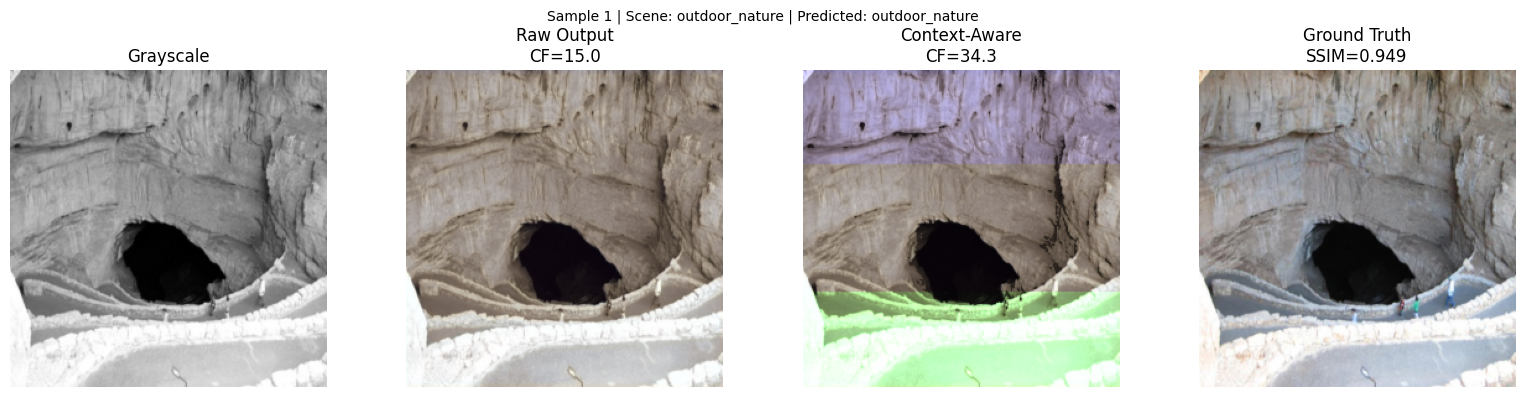

Sample 1 — Scene: outdoor_nature | CF(raw)=15.0 CF(ctx)=34.3 SSIM=0.949


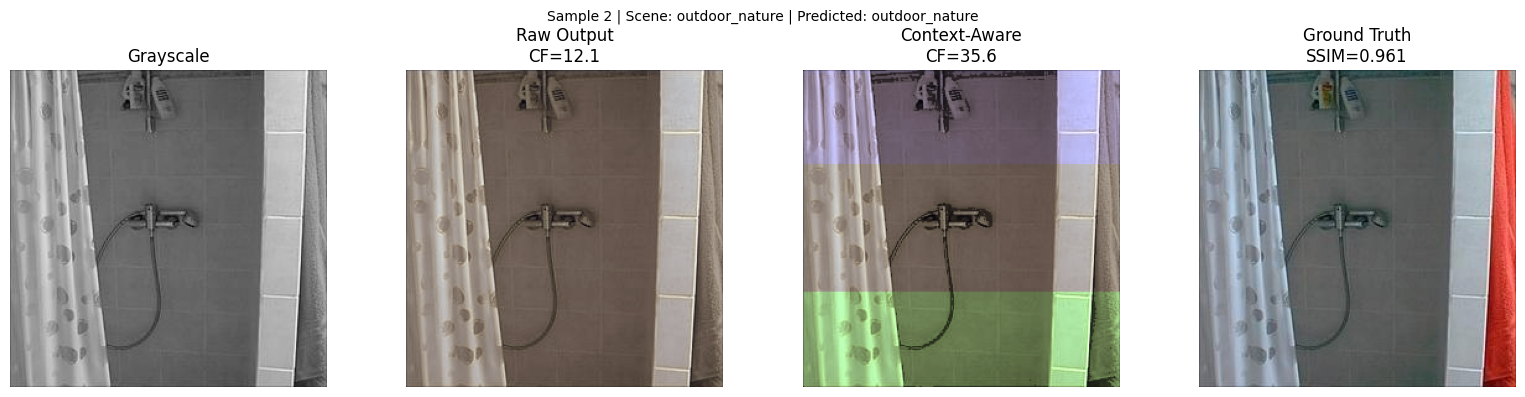

Sample 2 — Scene: outdoor_nature | CF(raw)=12.1 CF(ctx)=35.6 SSIM=0.961


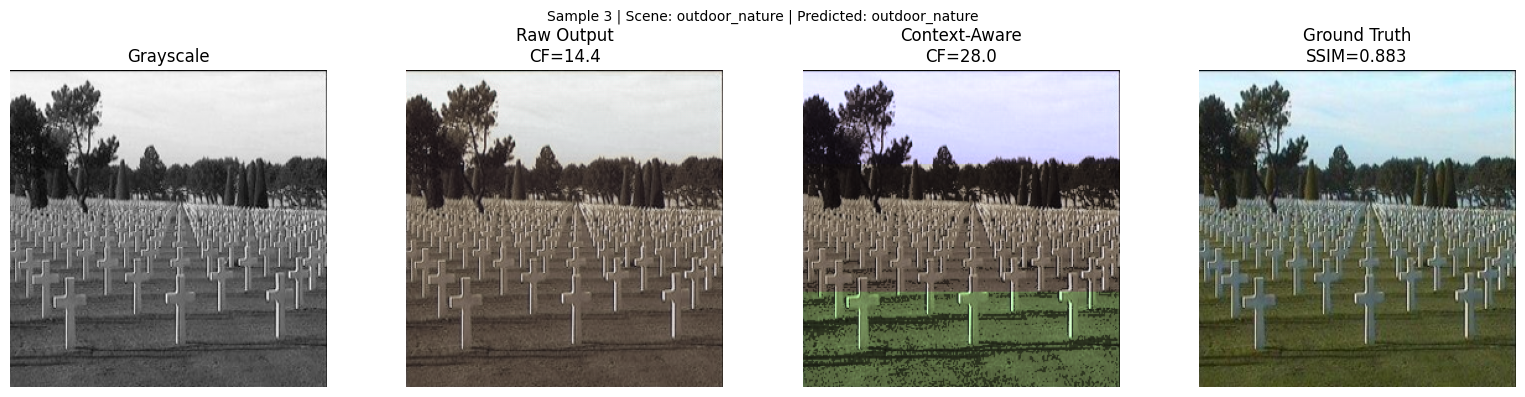

Sample 3 — Scene: outdoor_nature | CF(raw)=14.4 CF(ctx)=28.0 SSIM=0.883


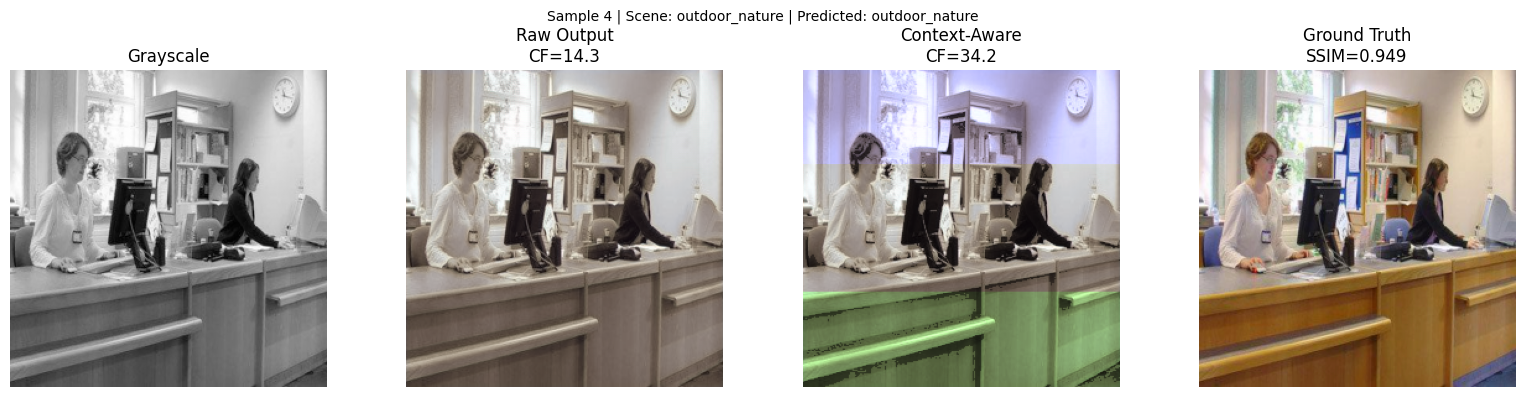

Sample 4 — Scene: outdoor_nature | CF(raw)=14.3 CF(ctx)=34.2 SSIM=0.949


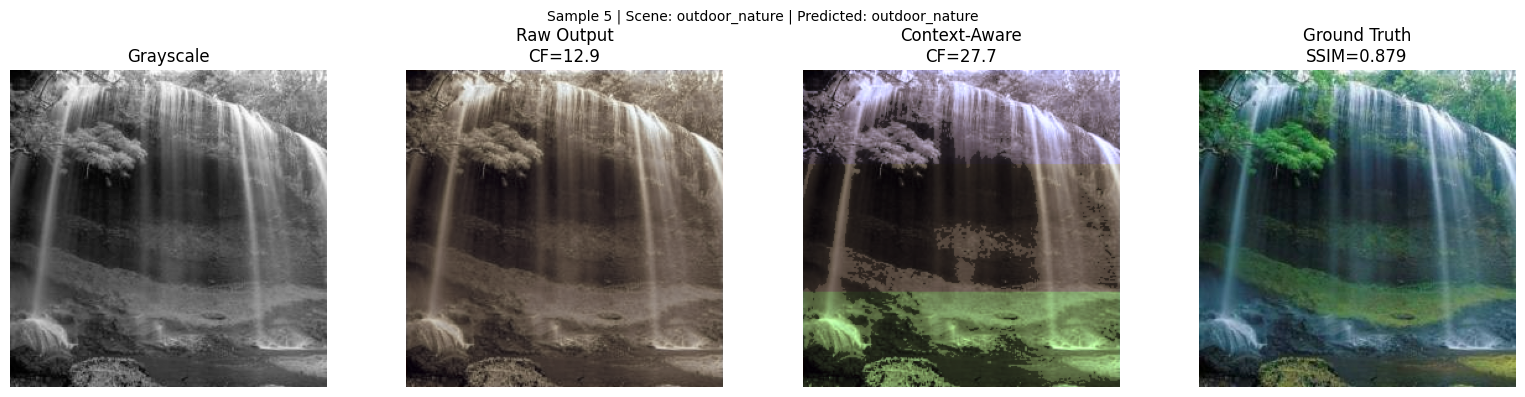

Sample 5 — Scene: outdoor_nature | CF(raw)=12.9 CF(ctx)=27.7 SSIM=0.879


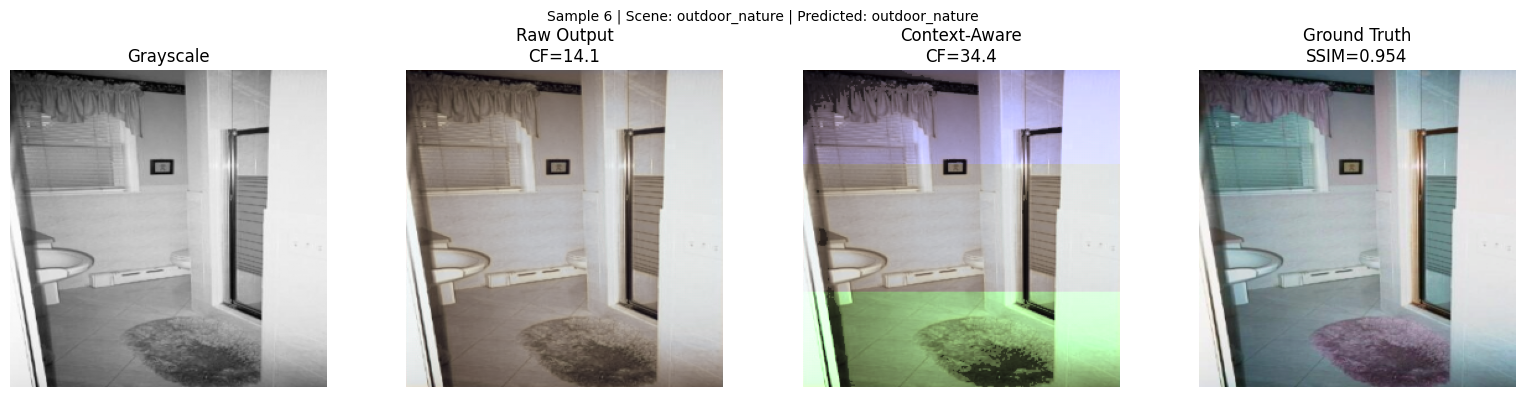

Sample 6 — Scene: outdoor_nature | CF(raw)=14.1 CF(ctx)=34.4 SSIM=0.954


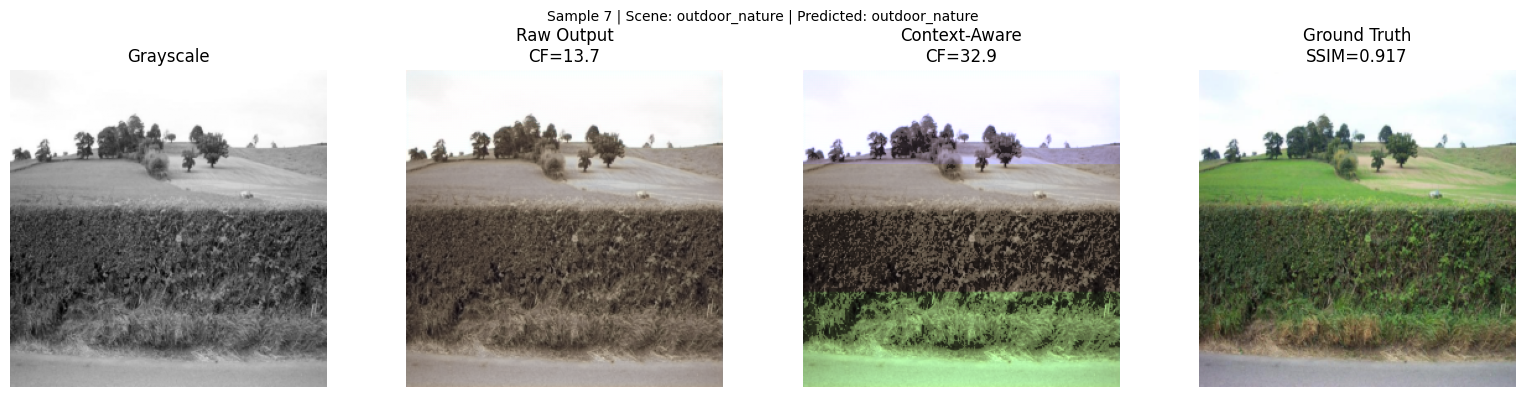

Sample 7 — Scene: outdoor_nature | CF(raw)=13.7 CF(ctx)=32.9 SSIM=0.917


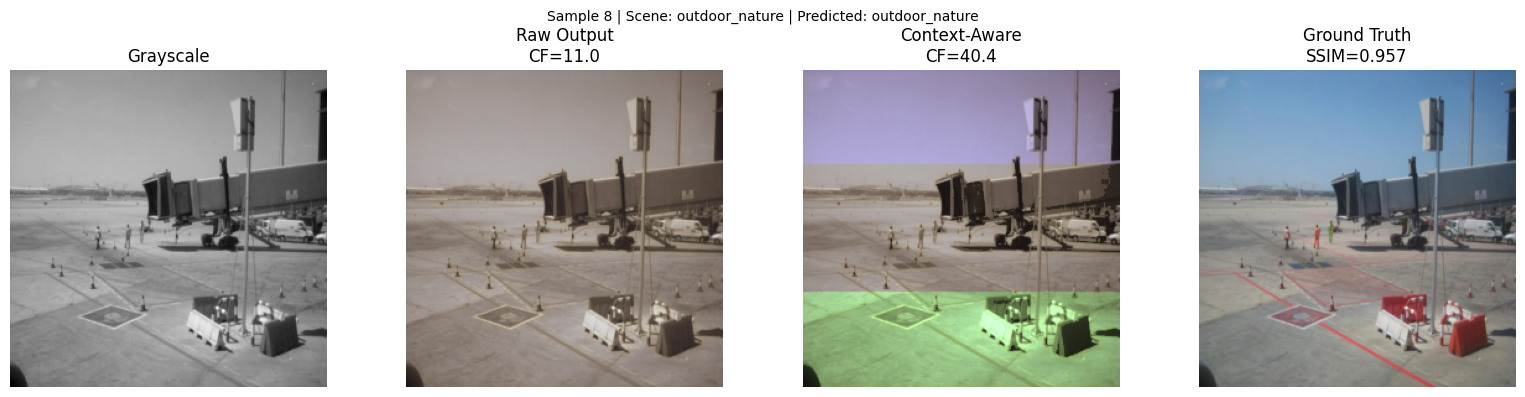

Sample 8 — Scene: outdoor_nature | CF(raw)=11.0 CF(ctx)=40.4 SSIM=0.957


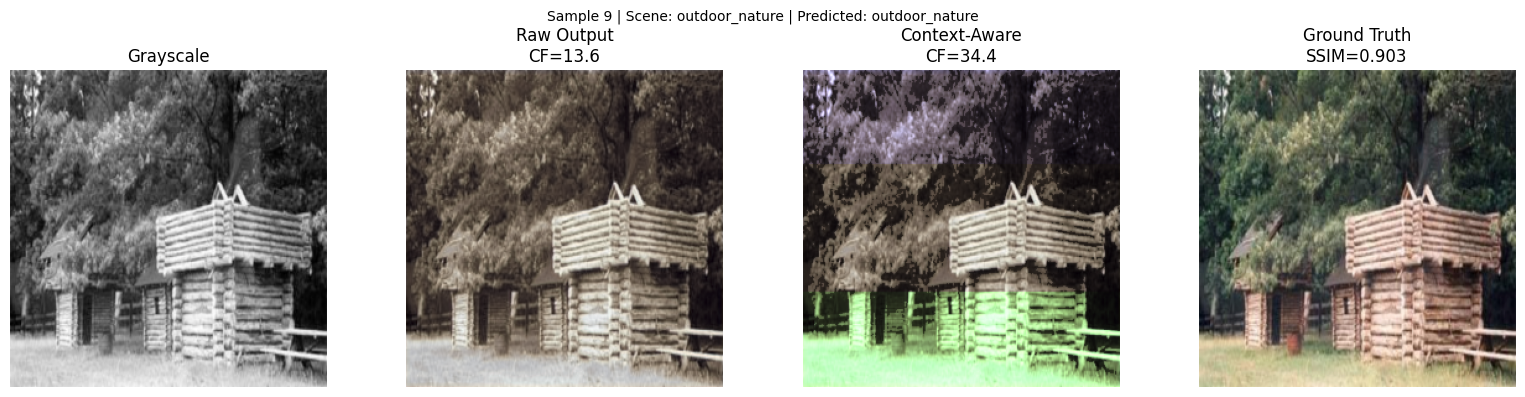

Sample 9 — Scene: outdoor_nature | CF(raw)=13.6 CF(ctx)=34.4 SSIM=0.903


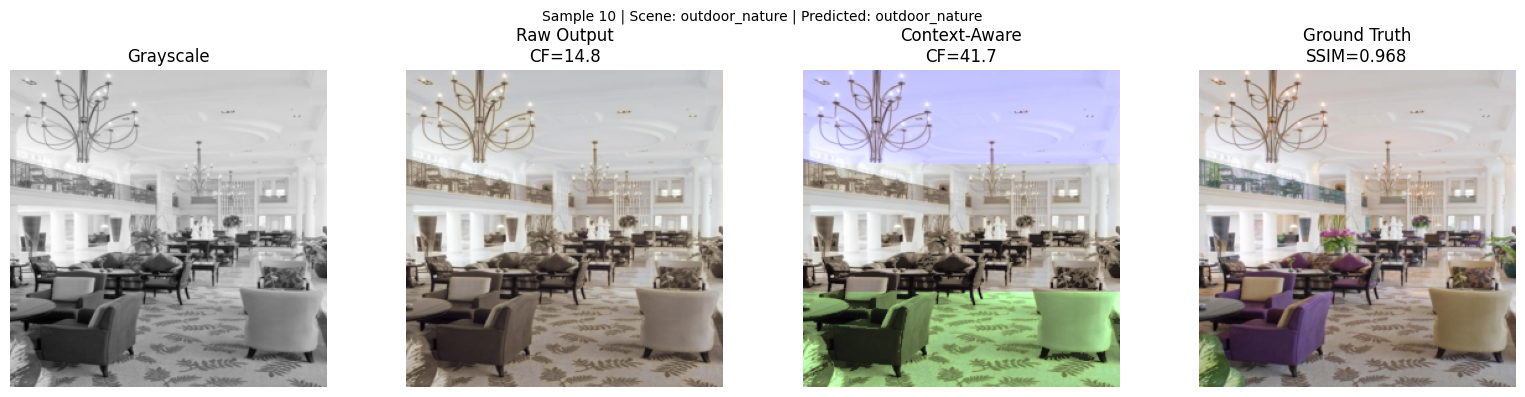

Sample 10 — Scene: outdoor_nature | CF(raw)=14.8 CF(ctx)=41.7 SSIM=0.968

All 10 results saved!


In [14]:
os.makedirs('gui_outputs', exist_ok=True)
model.eval(); scene_classifier.eval()

sample_ids = random.sample(range(len(val_set)), 10)

for i, idx in enumerate(sample_ids):
    inp, tgt_ab, img_cls, scene_lbl = val_set[idx]
    L_norm = inp[:1]

    with torch.no_grad():
        pred_ab    = model(inp.unsqueeze(0).to(device)).squeeze(0).cpu()
        scene_pred = scene_classifier(img_cls.unsqueeze(0).to(device))
        pred_scene_idx = scene_pred.argmax(dim=1).item()

    scene_name     = list(SCENE_TYPES.keys())[scene_lbl.item()]
    pred_scene_name = list(SCENE_TYPES.keys())[pred_scene_idx]

    rgb_raw  = lab_to_rgb(L_norm, pred_ab)
    L_gray   = (L_norm[0].numpy() + 1.0) / 2.0
    rgb_ctx  = apply_context_postprocess(rgb_raw, scene_name, L_gray)
    rgb_gt   = lab_to_rgb(L_norm, tgt_ab)
    gray     = np.clip((L_norm[0].numpy() + 1.0) * 127.5, 0, 255).astype(np.uint8)

    cf_r = compute_colorfulness(rgb_raw)
    cf_c = compute_colorfulness(rgb_ctx)
    ss   = compute_ssim(rgb_ctx, rgb_gt)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(gray, cmap='gray'); axes[0].set_title('Grayscale')
    axes[1].imshow(rgb_raw);           axes[1].set_title(f'Raw Output\nCF={cf_r:.1f}')
    axes[2].imshow(rgb_ctx);           axes[2].set_title(f'Context-Aware\nCF={cf_c:.1f}')
    axes[3].imshow(rgb_gt);            axes[3].set_title(f'Ground Truth\nSSIM={ss:.3f}')
    for ax in axes: ax.axis('off')
    plt.suptitle(f'Sample {i+1} | Scene: {scene_name} | Predicted: {pred_scene_name}', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'gui_outputs/result_{i+1}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Sample {i+1} — Scene: {scene_name} | CF(raw)={cf_r:.1f} CF(ctx)={cf_c:.1f} SSIM={ss:.3f}')

print('\nAll 10 results saved!')

## Step 15: Save All Outputs

In [15]:
os.makedirs('task3_outputs', exist_ok=True)

for f in ['scene_types.png', 'scene_distribution.png', 'training_curves.png', 'metrics_comparison.png']:
    if os.path.exists(f): shutil.copy(f, f'task3_outputs/{f}')

if os.path.exists(f'{CHECKPOINT_DIR}/best_model.pth'):
    shutil.copy(f'{CHECKPOINT_DIR}/best_model.pth', 'task3_outputs/best_model.pth')

summary = {
    'task':            'Task 3 - Context-Aware Colorization of Complex Scenes',
    'base_project':    'Real-Time Image Colorization (Training)',
    'new_features':    ['Scene classifier (ResNet50)', 'Scene one-hot input (6ch)',
                        'Context post-processing (sky/ground/shadow)', 'Dual loss training'],
    'dataset':         'ADE20K — 3000 images, 80/20 split',
    'epochs':          NUM_EPOCHS,
    'best_val_loss':   round(best_val_loss, 4),
    'scene_accuracy':  round(scene_accs_val[-1], 2),
    'mean_cf_raw':     round(float(np.mean(cf_raw)), 2),
    'mean_cf_context': round(float(np.mean(cf_ctx)), 2),
    'mean_ssim':       round(float(np.mean(ssim_scores)), 4),
}

with open('task3_outputs/metrics_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All outputs saved to task3_outputs/')
print(json.dumps(summary, indent=2))

All outputs saved to task3_outputs/
{
  "task": "Task 3 - Context-Aware Colorization of Complex Scenes",
  "base_project": "Real-Time Image Colorization (Training)",
  "new_features": [
    "Scene classifier (ResNet50)",
    "Scene one-hot input (6ch)",
    "Context post-processing (sky/ground/shadow)",
    "Dual loss training"
  ],
  "dataset": "ADE20K \u2014 3000 images, 80/20 split",
  "epochs": 5,
  "best_val_loss": 0.0049,
  "scene_accuracy": 100.0,
  "mean_cf_raw": 13.05,
  "mean_cf_context": 31.75,
  "mean_ssim": 0.9385
}


## Summary Table

| Component | Detail |
|-----------|--------|
| Base project | Real-Time Image Colorization (training project) |
| New addition | Scene classifier + context-aware post-processing |
| Model | ContextAwareColorizationUNet (6-channel input: L + scene one-hot) |
| Scene classifier | ResNet50 (5 scene types) |
| Dataset | ADE20K — 3000 images (2400 train / 600 val) |
| Epochs | 5 |
| Loss | SmoothL1 (color) + CrossEntropy (scene) |
| Key experiment | Raw output vs context-aware post-processing comparison |
| Metrics | Colorfulness, Saturation, SSIM, Scene Accuracy |